### This notebook captures all the models that could potentially help us make good predictions of smokers given our cleaned dataframe

Few things to note before we proceed 
1. Our dataset has imbalances in target variable '_RFSMOK3'
2. It has highly imbalanced features as well
3. Since we are more interested to know how many smokers are model is able to identify, we are interested in models that give us good prediction scores
    for imbalanced data.
4. From this high level overview, we want to evaluate the prediction capaciy of our model using 3 methods -
    1. CatBoost
    2. XGBoost
    3. LightGBM

### 1. Import X_train/X_test for Encoded and Original datasets

In [175]:
### 1. Data import from Feature Engineering Notebook
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
# Load training/ test data
#original data from data/modeling directory
# Load when needed
with open('../data/modeling/data_splits.pkl', 'rb') as f:
    data = pickle.load(f)
    X_train = data['X_train']
    X_test = data['X_test']
    y_train = data['y_train']
    y_test = data['y_test']

# Load encoded data from data/modeling directory
with open('../data/modeling/data_splits_encoded.pkl', 'rb') as f:
    encoded_data = pickle.load(f)
    X_train_encoded = encoded_data['X_train']
    X_test_encoded = encoded_data['X_test']
    y_train_encoded = encoded_data['y_train']
    y_test_encoded = encoded_data['y_test']



In [176]:
#check shape of the imported data
print(f"Encoded Train shape: {X_train_encoded.shape}, Test shape: {X_test_encoded.shape}")
print(f"Original Train shape: {X_train.shape}, Test shape: {X_test.shape}")
# check shape of the target variable
print(f"Encoded y_train shape: {y_train_encoded.shape}, y_test shape: {y_test_encoded.shape}")
print(f"Original y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")


Encoded Train shape: (1743268, 210), Test shape: (435817, 210)
Original Train shape: (1743268, 54), Test shape: (435817, 54)
Encoded y_train shape: (1743268,), y_test shape: (435817,)
Original y_train shape: (1743268,), y_test shape: (435817,)


In [177]:
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1743268 entries, 1267517 to 1629713
Columns: 210 entries, IDATE to _AGE65YR_2
dtypes: bool(203), datetime64[ns](1), float64(6)
memory usage: 443.9 MB


In [178]:
X_train_encoded.select_dtypes(include=['float64']).columns.tolist()

['IMONTH', 'PHYSHLTH', 'MENTHLTH', 'CHILDREN', 'WEIGHT2', 'HEIGHT3']

### 2. Apply Machine Learning Models

#### A. CATBOOST

#### 1. Default model

In [179]:
#generate a default CatBoost model
from catboost import CatBoostClassifier
import time
# Define categorical columns for CatBoost
catboost_categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove target column from categorical_cols if present
catboost_categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
# CatBoost model optimized for imbalanced classification
model = CatBoostClassifier(
    auto_class_weights='Balanced',
    cat_features=catboost_categorical_cols
)
# Fill missing values in categorical columns with string 'missing'
for col in catboost_categorical_cols:
    X_train[col] = X_train[col].astype(str).fillna('7')
    X_test[col] = X_test[col].astype(str).fillna('7')
print("Training CatBoost model...")

start = time.time()

model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True,
    verbose=100,
    plot=False
)

# model.fit(...)
end = time.time()


# Save the trained model
model.save_model('../data/modeling/catboost_model_default.cbm')

for col in catboost_categorical_cols:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype(str).fillna('7')

y_pred_cat = model.predict(X_test)
y_proba_cat = model.predict_proba(X_test)[:, 1]  # Probability of smoking


print("\n" + "="*80)
print("TIME TAKEN FOR TRAINING:")
print("="*80)
print(f"{end - start:.2f} seconds")

cat_time = end - start


Training CatBoost model...
Learning rate set to 0.200229
0:	learn: 0.6592009	test: 0.6589960	best: 0.6589960 (0)	total: 1.54s	remaining: 25m 39s
100:	learn: 0.5452945	test: 0.5460403	best: 0.5460403 (100)	total: 1m 38s	remaining: 14m 35s
200:	learn: 0.5404008	test: 0.5426666	best: 0.5426666 (200)	total: 3m 20s	remaining: 13m 15s
300:	learn: 0.5379378	test: 0.5414004	best: 0.5414004 (300)	total: 5m 1s	remaining: 11m 40s
400:	learn: 0.5362195	test: 0.5408798	best: 0.5408798 (400)	total: 6m 46s	remaining: 10m 7s
500:	learn: 0.5347879	test: 0.5404978	best: 0.5404978 (500)	total: 8m 33s	remaining: 8m 31s
600:	learn: 0.5336500	test: 0.5403403	best: 0.5403403 (600)	total: 10m 24s	remaining: 6m 54s
700:	learn: 0.5325590	test: 0.5401355	best: 0.5401295 (699)	total: 12m 32s	remaining: 5m 20s
800:	learn: 0.5315732	test: 0.5400546	best: 0.5400354 (786)	total: 14m 18s	remaining: 3m 33s
900:	learn: 0.5306528	test: 0.5399467	best: 0.5399430 (894)	total: 16m 5s	remaining: 1m 46s
999:	learn: 0.5297573	

#### 2. Tuned model

In [180]:

from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score


print("\n" + "="*80)
print("CATBOOST MODEL FOR IMBALANCED BINARY CLASSIFICATION")
print("="*80)

# Remove target column from categorical_cols if present
catboost_categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# CatBoost model optimized for imbalanced classification
tuned_model = CatBoostClassifier(
    # Basic parameters
    iterations=1000,
    learning_rate=0.1,
    depth=8,
    
    # Handle categorical features
    cat_features=catboost_categorical_cols,
    
    # Imbalance handling
    auto_class_weights='Balanced',  # Automatically balance class weights
    # Alternatively: class_weights={0: 1, 1: 10}  # Manual weights
    
    # Evaluation and early stopping
    eval_metric='AUC',  # Good for imbalanced data
    use_best_model=True,
    early_stopping_rounds=100,
    
    # Regularization to prevent overfitting
    l2_leaf_reg=3,
    bagging_temperature=0.5,
    
    # Performance
    random_seed=42,
    verbose=200,
    
    # Model interpretability
    leaf_estimation_method='Newton'
)


# Fill missing values in categorical columns with string 'missing'
for col in catboost_categorical_cols:
    X_train[col] = X_train[col].astype(str).fillna('7')
    X_test[col] = X_test[col].astype(str).fillna('7')


start = time.time()

print("Training CatBoost model...")
tuned_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    plot=False
)
end = time.time()

print(f"Training completed!")
print(f"Best iteration: {tuned_model.get_best_iteration()}")
print(f"Best validation AUC: {tuned_model.get_best_score()['validation']['AUC']:.4f}")

# Save the trained model
tuned_model.save_model('../data/modeling/catboost_model_tuned.cbm')

for col in catboost_categorical_cols:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype(str).fillna('7')

y_pred_cat_tuned = tuned_model.predict(X_test)
y_proba_cat_tuned = tuned_model.predict_proba(X_test)[:, 1]  # Probability of smoking


print("\n" + "="*80)
print("TIME TAKEN FOR TRAINING:")
print("="*80)
print(f"{end - start:.2f} seconds")

cat_tuned_time = end - start



CATBOOST MODEL FOR IMBALANCED BINARY CLASSIFICATION
Training CatBoost model...
0:	test: 0.7555299	best: 0.7555299 (0)	total: 1.57s	remaining: 26m 4s
200:	test: 0.8003975	best: 0.8003975 (200)	total: 5m 16s	remaining: 20m 58s
400:	test: 0.8023241	best: 0.8023241 (400)	total: 11m 31s	remaining: 17m 12s
600:	test: 0.8029246	best: 0.8029251 (599)	total: 16m 23s	remaining: 10m 52s
800:	test: 0.8031111	best: 0.8031180 (769)	total: 21m 22s	remaining: 5m 18s
999:	test: 0.8032480	best: 0.8032483 (996)	total: 26m 27s	remaining: 0us

bestTest = 0.8032482965
bestIteration = 996

Shrink model to first 997 iterations.
Training completed!
Best iteration: 996
Best validation AUC: 0.8032

TIME TAKEN FOR TRAINING:
2952.18 seconds


### B. LightGBM model

### 1. Default Model

In [181]:
# Import
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score
from lightgbm.callback import early_stopping  # Correct import

# Convert object columns to category
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# Get valid categorical columns
lightGBM_categorical_cols = X_train.select_dtypes(include='category').columns.tolist()

print("LightGBM Categorical Columns:")
print(lightGBM_categorical_cols)
print("="*80)

#Drop DATE columns from encoded data
X_train.drop(columns=['IDATE'], inplace=True, errors='ignore')
X_test.drop(columns=['IDATE'], inplace=True, errors='ignore')

# Define LightGBM model with basic parameters
lgbm_model = LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    num_leaves=31,
    learning_rate=0.1,
    n_estimators=1000,  # Set higher to allow early stopping
    random_state=42,
    class_weight='balanced'  # Handles class imbalance

)

start = time.time()
# Fit the model
lgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[early_stopping(stopping_rounds=50)],
    categorical_feature=lightGBM_categorical_cols  # Can be column names or indices
)
end = time.time()

# Save the trained LightGBM model
lgbm_model.booster_.save_model('../data/modeling/lightgbm_model_default.txt')

# Predict
y_pred_lgbm = lgbm_model.predict(X_test)
y_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

# Evaluate
print("AUC Score:", roc_auc_score(y_test, y_proba_lgbm))
print(classification_report(y_test, y_pred_lgbm))

print("\n" + "="*80)
print("TIME TAKEN FOR TRAINING:")
print("="*80)
print(f"{end - start:.2f} seconds")

lGBM_time = end - start


LightGBM Categorical Columns:
['DISPCODE', 'GENHLTH', 'HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2', 'CHCKIDNY', 'DIABETE3', 'SEX', 'MARITAL', 'RENTHOM1', 'VETERAN3', 'QLACTLM2', 'USEEQUIP', 'USENOW3', 'EXERANY2', 'PNEUVAC3', 'HIVTST6', 'QSTVER', '_RFHLTH', '_HCVU651', '_LTASTH1', '_CASTHM1', '_ASTHMS1', '_DRDXAR1', '_RFBMI5', '_CHLDCNT', '_EDUCAG', '_INCOMG', 'DRNKANY5', 'DROCDY3_', '_RFBING5', '_TOTINDA', '_RFSEAT3', 'YEAR', 'DIABETES', '_AGE65YR']
[LightGBM] [Info] Number of positive: 275822, number of negative: 1467446
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.828284
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.631085
[LightGBM] [Debug] init for col-wise cost 0.158122 seconds, init for row-wise cost 0.085779 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.171838 seconds.
You

### 2. Tuned Model

In [182]:
import time
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from lightgbm.callback import early_stopping
import joblib

# Convert object columns to category
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# Drop irrelevant date columns
X_train.drop(columns=['IDATE'], inplace=True, errors='ignore')
X_test.drop(columns=['IDATE'], inplace=True, errors='ignore')

# Categorical columns for LightGBM
categorical_cols = X_train.select_dtypes(include='category').columns.tolist()

# Base model
lgbm = LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    n_estimators=1000,  # Allows for early stopping
    random_state=42,
    class_weight='balanced'  # Helps with imbalance
)

# Hyperparameter distribution for randomized search
param_dist = {
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 5, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_samples': [20, 50, 100],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=3,
    verbose=False,
    n_jobs=1,
    random_state=42
)
start_time = time.time()

# Fit with early stopping
random_search.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[early_stopping(stopping_rounds=50, verbose=False)],
    categorical_feature=categorical_cols
)

end_time = time.time()
print(f"Training time: {end_time - start_time:.2f} seconds")

# Best model
best_lgbm = random_search.best_estimator_
print("Best Params:", random_search.best_params_)

# Save model
joblib.dump(best_lgbm, '../data/modeling/lightgbm_model_tuned.pkl')

# Predict and evaluate
y_pred_lgbm_tuned = best_lgbm.predict(X_test)
y_proba_lgbm_tuned = best_lgbm.predict_proba(X_test)[:, 1]

print("Tuned AUC Score:", roc_auc_score(y_test, y_proba_lgbm_tuned))
print(classification_report(y_test, y_pred_lgbm_tuned))

print("\n" + "="*80)
print("TIME TAKEN FOR TRAINING:")
print("="*80)
print(f"{end - start:.2f} seconds")

lGBM_tuned_time = end - start


[LightGBM] [Info] Number of positive: 183881, number of negative: 978297
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.828033
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.630967
[LightGBM] [Debug] init for col-wise cost 0.030265 seconds, init for row-wise cost 0.054603 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040168 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 641
[LightGBM] [Info] Number of data points in the train set: 1162178, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 9
[LightGB

### MODEL EVALUATION

#### 1. Base results

In [183]:
from sklearn.metrics import accuracy_score, average_precision_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
import pandas as pd
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score



def evaluate_model(model, y_test, y_pred, y_proba, categorical_cols, model_type):
    print("\n" + "="*80)
    print(f"{model_type} EVALUATION")
    print("="*80)


    # Comprehensive evaluation metrics for imbalanced data
    print("Classification Metrics:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall (Sensitivity): {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print(f"PR-AUC: {average_precision_score(y_test, y_proba):.4f}")

    # Detailed classification report
    print(f"\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    print(f"\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, 
                        index=['Actual Non-smoking', 'Actual Smoking'],
                        columns=['Predicted Non-smoking', 'Predicted Smoking'])
    print(cm_df)

    # Smoking Detection Breakdown
    tn, fp, fn, tp = cm.ravel()
    print(f"\nSmoking Detection Metrics:")
    print(f"True Positives (Smokers caught): {tp}")
    print(f"False Positives (False alarms): {fp}")
    print(f"False Negatives (Missed smokers): {fn}")
    print(f"True Negatives (Correctly identified non-smokers): {tn}")
    print(f"False Positive Rate: {fp / (fp + tn):.4f}")
    print(f"False Negative Rate: {fn / (fn + tp):.4f}")

    print("\n" + "="*80)
    print("FEATURE IMPORTANCE")
    print("="*80)

    # Use feature_importances_ and feature names from X_train
    if model_type == "LightGBM":
        feature_importance = model.feature_importances_
        feature_names = model.feature_name_
    else:
        feature_importance = model.get_feature_importance()
        feature_names = model.feature_names_

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance,
        'type': ['Categorical' if col in categorical_cols else 'Numerical' 
                for col in feature_names]
    }).sort_values('importance', ascending=False)

    print("Top 15 Most Important Features:")
    print(importance_df.head(15))

    print(f"\nImportance by feature type:")
    type_importance = importance_df.groupby('type')['importance'].sum()
    print(type_importance)

    return cm_df, tn, fp, fn, tp, importance_df, type_importance



#### 2. Best Threshold result

In [184]:
from sklearn.metrics import accuracy_score, average_precision_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
import pandas as pd
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score



def evaluate_model_best_threshold(model, y_test, y_pred, y_proba, categorical_cols, model_type):
    print("\n" + "="*80)
    print(f"{model_type} EVALUATION")
    print("="*80)

    #get best threashold for precision-recall curve
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, precision[:-1], label="Precision", color="b")
    plt.plot(thresholds, recall[:-1], label="Recall", color="g")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Precision-Recall vs Threshold")
    plt.legend()
    plt.grid(True)
    plt.show()


    # Compute F1 score efficiently: F1 = 2 * (P * R) / (P + R)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)

    # Find best threshold
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    print("Best F1 Threshold:", best_threshold)

    # Apply best threshold to predictions
    y_pred_custom = (y_proba >= best_threshold).astype(int)

    # Comprehensive evaluation metrics for imbalanced data
    print("Classification Metrics:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_custom):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_custom):.4f}")
    print(f"Recall (Sensitivity): {recall_score(y_test, y_pred_custom):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred_custom):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print(f"PR-AUC: {average_precision_score(y_test, y_proba):.4f}")

    # Detailed classification report
    print(f"\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred_custom))

    # Confusion Matrix
    print(f"\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred_custom)
    cm_df = pd.DataFrame(cm, 
                        index=['Actual Non-smoking', 'Actual Smoking'],
                        columns=['Predicted Non-smoking', 'Predicted Smoking'])
    print(cm_df)

    # Smoking Detection Breakdown
    tn, fp, fn, tp = cm.ravel()
    print(f"\nSmoking Detection Metrics:")
    print(f"True Positives (Smokers caught): {tp}")
    print(f"False Positives (False alarms): {fp}")
    print(f"False Negatives (Missed smokers): {fn}")
    print(f"True Negatives (Correctly identified non-smokers): {tn}")
    print(f"False Positive Rate: {fp / (fp + tn):.4f}")
    print(f"False Negative Rate: {fn / (fn + tp):.4f}")

    print("\n" + "="*80)
    print("FEATURE IMPORTANCE")
    print("="*80)

    # Use feature_importances_ and feature names from X_train
    if model_type == "LightGBM":
        feature_importance = model.feature_importances_
        feature_names = model.feature_name_
    else:
        feature_importance = model.get_feature_importance()
        feature_names = model.feature_names_

    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance,
        'type': ['Categorical' if col in categorical_cols else 'Numerical' 
                for col in feature_names]
    }).sort_values('importance', ascending=False)

    print("Top 15 Most Important Features:")
    print(importance_df.head(15))

    print(f"\nImportance by feature type:")
    type_importance = importance_df.groupby('type')['importance'].sum()
    print(type_importance)

    return cm_df, tn, fp, fn, tp, importance_df, type_importance




CatBoost EVALUATION
Classification Metrics:
Accuracy: 0.7349
Precision: 0.3402
Recall (Sensitivity): 0.7190
F1-Score: 0.4619
ROC-AUC: 0.8031
PR-AUC: 0.4721

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.74      0.82    366861
           1       0.34      0.72      0.46     68956

    accuracy                           0.73    435817
   macro avg       0.64      0.73      0.64    435817
weighted avg       0.84      0.73      0.77    435817


Confusion Matrix:
                    Predicted Non-smoking  Predicted Smoking
Actual Non-smoking                 270720              96141
Actual Smoking                      19374              49582

Smoking Detection Metrics:
True Positives (Smokers caught): 49582
False Positives (False alarms): 96141
False Negatives (Missed smokers): 19374
True Negatives (Correctly identified non-smokers): 270720
False Positive Rate: 0.2621
False Negative Rate: 0.2810

FEATURE IMPORTANCE
To

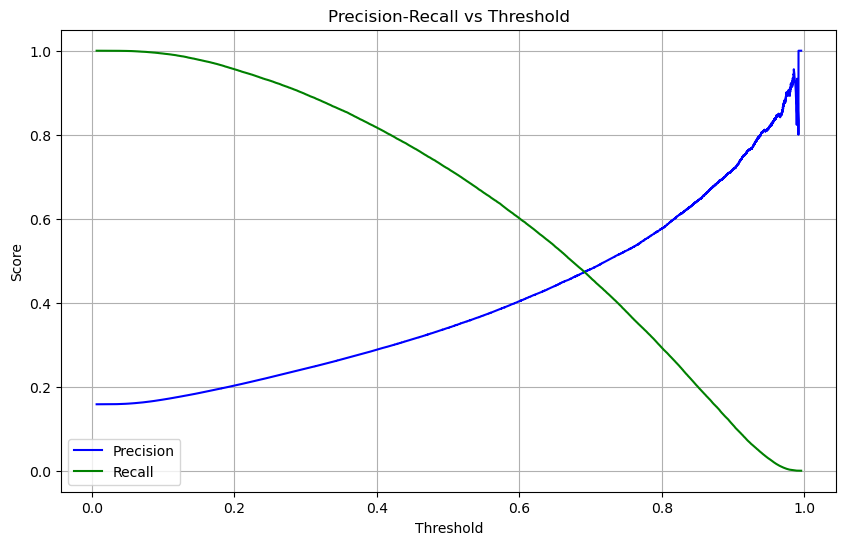

Best F1 Threshold: 0.6190492071138165
Classification Metrics:
Accuracy: 0.8057
Precision: 0.4174
Recall (Sensitivity): 0.5771
F1-Score: 0.4845
ROC-AUC: 0.8031
PR-AUC: 0.4721

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88    366861
           1       0.42      0.58      0.48     68956

    accuracy                           0.81    435817
   macro avg       0.67      0.71      0.68    435817
weighted avg       0.84      0.81      0.82    435817


Confusion Matrix:
                    Predicted Non-smoking  Predicted Smoking
Actual Non-smoking                 311327              55534
Actual Smoking                      29161              39795

Smoking Detection Metrics:
True Positives (Smokers caught): 39795
False Positives (False alarms): 55534
False Negatives (Missed smokers): 29161
True Negatives (Correctly identified non-smokers): 311327
False Positive Rate: 0.1514
False Negative Rate: 0.4229

FEAT

In [185]:
# Evaluate the CatBoost model
# base evaluation
cm_df_cat, tn_cat, fp_cat, fn_cat, tp_cat, importance_df_cat, type_importance_cat = evaluate_model(model, y_test, y_pred_cat, y_proba_cat, catboost_categorical_cols, "CatBoost")
# Evaluate the CatBoost model with best threshold
cm_df_cat_best, tn_cat_best, fp_cat_best, fn_cat_best, tp_cat_best, importance_df_cat_best, type_importance_cat_best = evaluate_model_best_threshold(model, y_test, y_pred_cat, y_proba_cat, catboost_categorical_cols, "CatBoost")


CatBoost Tuned EVALUATION
Classification Metrics:
Accuracy: 0.7365
Precision: 0.3414
Recall (Sensitivity): 0.7162
F1-Score: 0.4624
ROC-AUC: 0.8032
PR-AUC: 0.4727

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.74      0.83    366861
           1       0.34      0.72      0.46     68956

    accuracy                           0.74    435817
   macro avg       0.64      0.73      0.64    435817
weighted avg       0.84      0.74      0.77    435817


Confusion Matrix:
                    Predicted Non-smoking  Predicted Smoking
Actual Non-smoking                 271607              95254
Actual Smoking                      19568              49388

Smoking Detection Metrics:
True Positives (Smokers caught): 49388
False Positives (False alarms): 95254
False Negatives (Missed smokers): 19568
True Negatives (Correctly identified non-smokers): 271607
False Positive Rate: 0.2596
False Negative Rate: 0.2838

FEATURE IMPORTA

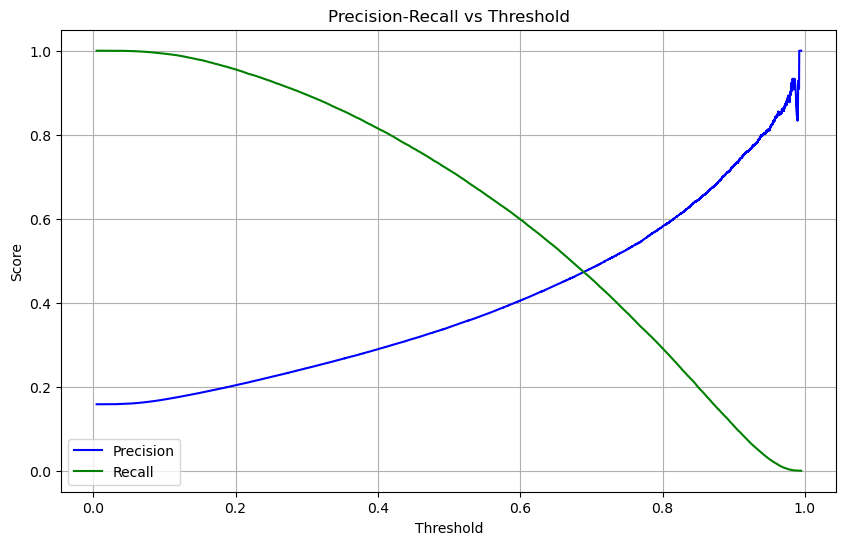

Best F1 Threshold: 0.6259964152462564
Classification Metrics:
Accuracy: 0.8098
Precision: 0.4241
Recall (Sensitivity): 0.5646
F1-Score: 0.4844
ROC-AUC: 0.8032
PR-AUC: 0.4727

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.86      0.88    366861
           1       0.42      0.56      0.48     68956

    accuracy                           0.81    435817
   macro avg       0.67      0.71      0.68    435817
weighted avg       0.84      0.81      0.82    435817


Confusion Matrix:
                    Predicted Non-smoking  Predicted Smoking
Actual Non-smoking                 313993              52868
Actual Smoking                      30025              38931

Smoking Detection Metrics:
True Positives (Smokers caught): 38931
False Positives (False alarms): 52868
False Negatives (Missed smokers): 30025
True Negatives (Correctly identified non-smokers): 313993
False Positive Rate: 0.1441
False Negative Rate: 0.4354

FEAT

In [186]:
#evaluate catboost tuned model
# base model
cm_df_cat_tuned, tn_cat_tuned, fp_cat_tuned, fn_cat_tuned, tp_cat_tuned, importance_df_cat_tuned, type_importance_cat_tuned= evaluate_model(tuned_model, y_test, y_pred_cat_tuned, y_proba_cat_tuned, catboost_categorical_cols, "CatBoost Tuned")
# best threshold
cm_df_cat_tune_best, tn_cat_tune_best, fp_cat_tune_best, fn_cat_tune_best, tp_cat_tune_best, importance_df_cat_tune_best, type_importance_cat_tune_best = evaluate_model_best_threshold(tuned_model, y_test, y_pred_cat_tuned, y_proba_cat_tuned, catboost_categorical_cols, "CatBoost Tuned")


LightGBM EVALUATION
Classification Metrics:
Accuracy: 0.7354
Precision: 0.3402
Recall (Sensitivity): 0.7157
F1-Score: 0.4612
ROC-AUC: 0.8019
PR-AUC: 0.4695

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.74      0.82    366861
           1       0.34      0.72      0.46     68956

    accuracy                           0.74    435817
   macro avg       0.64      0.73      0.64    435817
weighted avg       0.84      0.74      0.77    435817


Confusion Matrix:
                    Predicted Non-smoking  Predicted Smoking
Actual Non-smoking                 271154              95707
Actual Smoking                      19607              49349

Smoking Detection Metrics:
True Positives (Smokers caught): 49349
False Positives (False alarms): 95707
False Negatives (Missed smokers): 19607
True Negatives (Correctly identified non-smokers): 271154
False Positive Rate: 0.2609
False Negative Rate: 0.2843

FEATURE IMPORTANCE
To

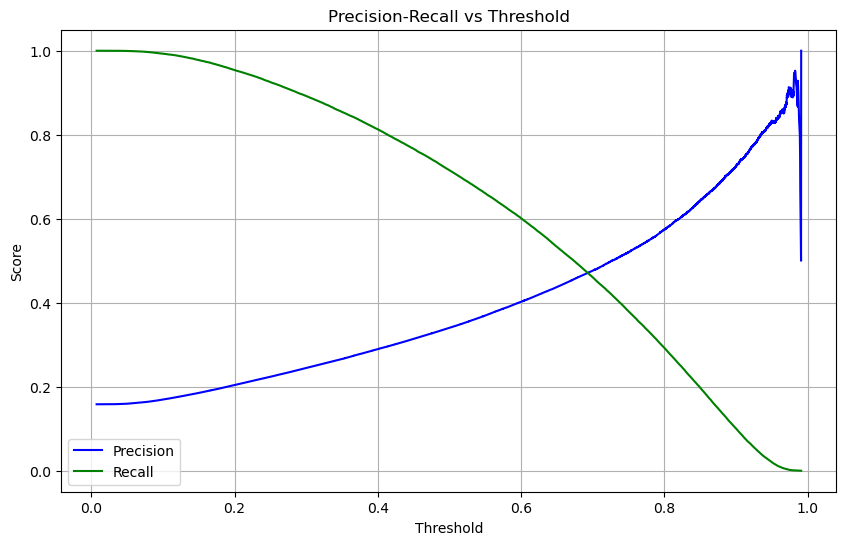

Best F1 Threshold: 0.6188384155747456
Classification Metrics:
Accuracy: 0.8045
Precision: 0.4153
Recall (Sensitivity): 0.5768
F1-Score: 0.4829
ROC-AUC: 0.8019
PR-AUC: 0.4695

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88    366861
           1       0.42      0.58      0.48     68956

    accuracy                           0.80    435817
   macro avg       0.66      0.71      0.68    435817
weighted avg       0.84      0.80      0.82    435817


Confusion Matrix:
                    Predicted Non-smoking  Predicted Smoking
Actual Non-smoking                 310861              56000
Actual Smoking                      29181              39775

Smoking Detection Metrics:
True Positives (Smokers caught): 39775
False Positives (False alarms): 56000
False Negatives (Missed smokers): 29181
True Negatives (Correctly identified non-smokers): 310861
False Positive Rate: 0.1526
False Negative Rate: 0.4232

FEAT

In [187]:
#evaluate the LightGBM model, 
# basic model
cm_df_lgbm, tn_lgbm, fp_lgbm, fn_lgbm, tp_lgbm, importance_df_lgbm, type_importance_lgbm = evaluate_model(lgbm_model, y_test, y_pred_lgbm, y_proba_lgbm, lightGBM_categorical_cols, "LightGBM")
# evaluate the LightGBM model with best threshold
cm_df_lgbm_best, tn_lgbm_best, fp_lgbm_best, fn_lgbm_best, tp_lgbm_best, importance_df_lgbm_best, type_importance_lgbm_best = evaluate_model_best_threshold(lgbm_model, y_test, y_pred_lgbm, y_proba_lgbm, lightGBM_categorical_cols, "LightGBM")


LightGBM EVALUATION
Classification Metrics:
Accuracy: 0.7387
Precision: 0.3430
Recall (Sensitivity): 0.7114
F1-Score: 0.4628
ROC-AUC: 0.8026
PR-AUC: 0.4713

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.74      0.83    366861
           1       0.34      0.71      0.46     68956

    accuracy                           0.74    435817
   macro avg       0.64      0.73      0.65    435817
weighted avg       0.84      0.74      0.77    435817


Confusion Matrix:
                    Predicted Non-smoking  Predicted Smoking
Actual Non-smoking                 272900              93961
Actual Smoking                      19902              49054

Smoking Detection Metrics:
True Positives (Smokers caught): 49054
False Positives (False alarms): 93961
False Negatives (Missed smokers): 19902
True Negatives (Correctly identified non-smokers): 272900
False Positive Rate: 0.2561
False Negative Rate: 0.2886

FEATURE IMPORTANCE
To

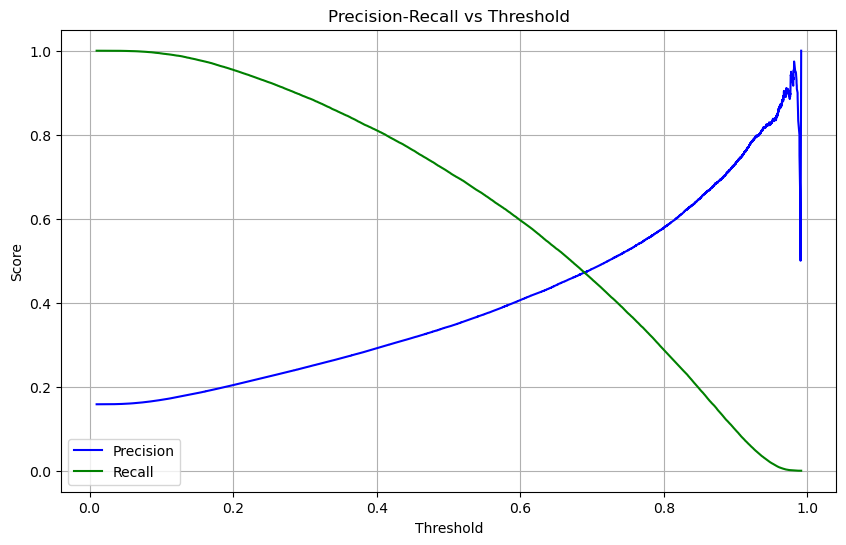

Best F1 Threshold: 0.6163746682433768
Classification Metrics:
Accuracy: 0.8060
Precision: 0.4180
Recall (Sensitivity): 0.5760
F1-Score: 0.4844
ROC-AUC: 0.8026
PR-AUC: 0.4713

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88    366861
           1       0.42      0.58      0.48     68956

    accuracy                           0.81    435817
   macro avg       0.67      0.71      0.68    435817
weighted avg       0.84      0.81      0.82    435817


Confusion Matrix:
                    Predicted Non-smoking  Predicted Smoking
Actual Non-smoking                 311545              55316
Actual Smoking                      29235              39721

Smoking Detection Metrics:
True Positives (Smokers caught): 39721
False Positives (False alarms): 55316
False Negatives (Missed smokers): 29235
True Negatives (Correctly identified non-smokers): 311545
False Positive Rate: 0.1508
False Negative Rate: 0.4240

FEAT

In [188]:
#evaluate the LightGBM tuned model
# base model
cm_df_lgbm_tuned, tn_lgbm_tuned, fp_lgbm_tuned, fn_lgbm_tuned, tp_lgbm_tuned, importance_df_lgbm_tuned, type_importance_lgbm_tuned = evaluate_model(best_lgbm, y_test, y_pred_lgbm_tuned, y_proba_lgbm_tuned, lightGBM_categorical_cols, "LightGBM")
# best threshold
cm_df_lgbm_tune_best, tn_lgbm_tune_best, fp_lgbm_tune_best, fn_lgbm_tune_best, tp_lgbm_tune_best, importance_df_lgbm_tune_best, type_importance_lgbm_tune_best = evaluate_model_best_threshold(best_lgbm, y_test, y_pred_lgbm_tuned, y_proba_lgbm_tuned, lightGBM_categorical_cols, "LightGBM")

## Compare 4 models

In [191]:
### Compare values of Accuracy, Precision, Recall, F1-Score, ROC-AUC, PR-AUC for all models, also time taken for training
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score





import numpy as np
# Create a DataFrame to compare metrics
comparison_df = pd.DataFrame({
    'Model': ['CatBoost', 'CatBoost Tuned', 'LightGBM', 'LightGBM Tuned'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_cat),
        accuracy_score(y_test, y_pred_cat_tuned),
        accuracy_score(y_test, y_pred_lgbm),
        accuracy_score(y_test, y_pred_lgbm_tuned)
    ],
    'Precision': [
        precision_score(y_test, y_pred_cat),
        precision_score(y_test, y_pred_cat_tuned),
        precision_score(y_test, y_pred_lgbm),
        precision_score(y_test, y_pred_lgbm_tuned)
    ],
    'Recall': [
        recall_score(y_test, y_pred_cat),
        recall_score(y_test, y_pred_cat_tuned),
        recall_score(y_test, y_pred_lgbm),
        recall_score(y_test, y_pred_lgbm_tuned)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_cat),
        f1_score(y_test, y_pred_cat_tuned),
        f1_score(y_test, y_pred_lgbm),
        f1_score(y_test, y_pred_lgbm_tuned)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_cat),
        roc_auc_score(y_test, y_proba_cat_tuned),
        roc_auc_score(y_test, y_proba_lgbm),
        roc_auc_score(y_test, y_proba_lgbm_tuned)
    ],
    'PR-AUC': [
        average_precision_score(y_test, y_proba_cat),
        average_precision_score(y_test, y_proba_cat_tuned),
        average_precision_score(y_test, y_proba_lgbm),
        average_precision_score(y_test, y_proba_lgbm_tuned)
    ],
    'Training Time': [
        cat_time,
        cat_tuned_time,
        lGBM_time,
        lGBM_tuned_time
    ]
})
# Set Model as index
comparison_df.set_index('Model', inplace=True)
# Display the comparison DataFrame
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df)



MODEL COMPARISON
                Accuracy  Precision    Recall  F1-Score   ROC-AUC    PR-AUC  \
Model                                                                         
CatBoost        0.734946   0.340248  0.719038  0.461918  0.803057  0.472089   
CatBoost Tuned  0.736536   0.341450  0.716225  0.462439  0.803248  0.472651   
LightGBM        0.735407   0.340207  0.715659  0.461180  0.801914  0.469531   
LightGBM Tuned  0.738737   0.342999  0.711381  0.462837  0.802552  0.471335   

                Training Time  
Model                          
CatBoost          1695.308031  
CatBoost Tuned    2952.177715  
LightGBM            20.061425  
LightGBM Tuned      20.061425  


### Top 15 features in all these algorithms

#### 1. TRAINING TIME: The results are almost similar for all models however we notice that **Light GBM Tuned** is the best model in terms of results and time taken to predict (20 s).
#### 2. GOOD RECALL: Since our primary goal was to figure out the factors that are responsible or contribute towards a person smoking, we are more interested in the Recall (so that we want identify all possible smokers for Public Health Intervention) of our model and therefore **Light GBM Tuned** is the best.
#### 3. F1-SCORE: Our model **Light GBM Tuned** also gives the best F1-score i.e Precision to recall Ratio is best for this case, this shows that the results are balanced for behaviour study
#### 4. PR-AUC: Our model scores third best when compared to Catboost and Catboost Tuned models which take a really long training time (~ 1700 - 3000 s) compared to our model with takes (20 s)

### TOP PREDICTORS OF SMOKERS

#### 1. Best model TOP 20 Predictors

In [193]:
print(importance_df_lgbm_tune_best.head(20)), print(type_importance_lgbm_tune_best)

     feature  importance         type
45  DROCDY3_        7001  Categorical
25   WEIGHT2        6786    Numerical
26   HEIGHT3        4444    Numerical
21   MARITAL        2601  Categorical
0     IMONTH        2547    Numerical
43   _INCOMG        2511  Categorical
33    QSTVER        2394  Categorical
3   PHYSHLTH        2383    Numerical
4   MENTHLTH        2175    Numerical
2    GENHLTH        1920  Categorical
42   _EDUCAG        1830  Categorical
49      YEAR        1463  Categorical
24  CHILDREN        1463    Numerical
31  PNEUVAC3        1425  Categorical
32   HIVTST6        1395  Categorical
35  _HCVU651        1376  Categorical
22  RENTHOM1        1354  Categorical
15  CHCCOPD1        1283  Categorical
6   PERSDOC2        1151  Categorical
30  EXERANY2        1123  Categorical
type
Categorical    49162
Numerical      19798
Name: importance, dtype: int32


(None, None)

In [190]:
# compare teh top 15 features of all models and find the common ones

top_features = pd.concat([
    importance_df_cat.head(15),
    importance_df_cat_tuned.head(15),
    importance_df_lgbm.head(15),
    importance_df_lgbm_tuned.head(15)
]).drop_duplicates(subset='feature').reset_index(drop=True)
print("\n" + "="*80)
print("TOP 15 FEATURES ACROSS ALL MODELS")
print("="*80)
print(top_features)


TOP 15 FEATURES ACROSS ALL MODELS
     feature  importance         type
0    _EDUCAG   13.378780  Categorical
1    MARITAL    7.361560  Categorical
2   _RFBING5    6.120611  Categorical
3    WEIGHT2    5.804533    Numerical
4   _HCVU651    4.974224  Categorical
5   _AGE65YR    4.938634  Categorical
6    GENHLTH    4.497697  Categorical
7   CHCCOPD1    4.238240  Categorical
8    HEIGHT3    4.176473    Numerical
9    _RFBMI5    3.731788  Categorical
10   HIVTST6    2.808390  Categorical
11   _INCOMG    2.717682  Categorical
12  MENTHLTH    2.566413    Numerical
13  EXERANY2    2.469563  Categorical
14  RENTHOM1    2.224335  Categorical
15  DROCDY3_    2.252274  Categorical
16  ADDEPEV2    2.199912  Categorical
17    QSTVER  936.000000  Categorical
18    IMONTH  762.000000    Numerical
19  PHYSHLTH  672.000000    Numerical
20  CHILDREN  478.000000    Numerical
21  PNEUVAC3  471.000000  Categorical
22      YEAR  466.000000  Categorical


It opens up conversations about the factors in HBM model and if we plot the influence of the various components of the HBM model in predicting if a person smokes. We will try to look into each of these factors in detail in our reporting phase